In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
import zipfile

zip_path = '/content/drive/MyDrive/MachineLearningCSV.zip'
extract_path = '/content/drive/MyDrive/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [36]:
import pandas as pd
import os

path = '/content/drive/MyDrive/data/MachineLearningCVE'

all_files = os.listdir(path)

df_list = []

for file in all_files:
    if file.endswith('.csv'):
        df_temp = pd.read_csv(os.path.join(path, file))
        df_temp.columns = df_temp.columns.str.strip()
        df_list.append(df_temp)

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

(2830743, 79)


In [37]:
df = df.sample(500, random_state=42)

In [38]:
selected_cols = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s',
    'Flow Packets/s'
]

df = df[selected_cols + ['Label']]

In [39]:
df = df.dropna()
df.columns = df.columns.str.strip()

In [40]:
def row_to_text(row):
    return f"""
    Flow Duration: {row['Flow Duration']},
    Forward Packets: {row['Total Fwd Packets']},
    Backward Packets: {row['Total Backward Packets']},
    Bytes per second: {row['Flow Bytes/s']},
    Packets per second: {row['Flow Packets/s']}
    """

df['text'] = df.apply(row_to_text, axis=1)

In [41]:
df['Label'] = df['Label'].str.lower()
df['Label'] = df['Label'].apply(lambda x: 'normal' if x == 'benign' else 'attack')

In [42]:
df_test = df.sample(20, random_state=42)

In [67]:
from transformers import pipeline

generator = pipeline("text-generation", model="gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [68]:
def classify_gpt2(text):
    prompt = f"""You are a cybersecurity expert.
Classify the following network traffic as Normal or Attack.

{text}

Answer:"""

    result = generator(
        prompt,
        max_new_tokens=3,
        do_sample=False
    )

    output = result[0]['generated_text'].lower()

    if "normal" in output:
        return "normal"
    elif "attack" in output:
        return "attack"
    else:
        return "normal"  # fallback

In [69]:
df_test['prediction'] = df_test['text'].apply(classify_gpt2)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50

In [70]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("Accuracy:", accuracy_score(df_test['Label'], df_test['prediction']))
print("F1 Score:", f1_score(df_test['Label'], df_test['prediction'], pos_label='attack'))

print(classification_report(df_test['Label'], df_test['prediction']))

Accuracy: 0.6
F1 Score: 0.0
              precision    recall  f1-score   support

      attack       0.00      0.00      0.00         2
      normal       0.60      1.00      0.75         3

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [72]:
df_test1 = df.sample(20, random_state=42)
df_test1['prediction'] = df_test1['text'].apply(classify_gpt2)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50

In [73]:
df_test2 = df.sample(20, random_state=100)
df_test2['prediction'] = df_test2['text'].apply(classify_gpt2)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50

In [74]:
df_test3 = df.sample(20, random_state=7)
df_test3['prediction'] = df_test3['text'].apply(classify_gpt2)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=3) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Setting `pad_token_id` to `eos_token_id`:50

In [75]:
print(accuracy_score(df_test1['Label'], df_test1['prediction']))
print(accuracy_score(df_test2['Label'], df_test2['prediction']))
print(accuracy_score(df_test3['Label'], df_test3['prediction']))

0.7
0.9
0.65


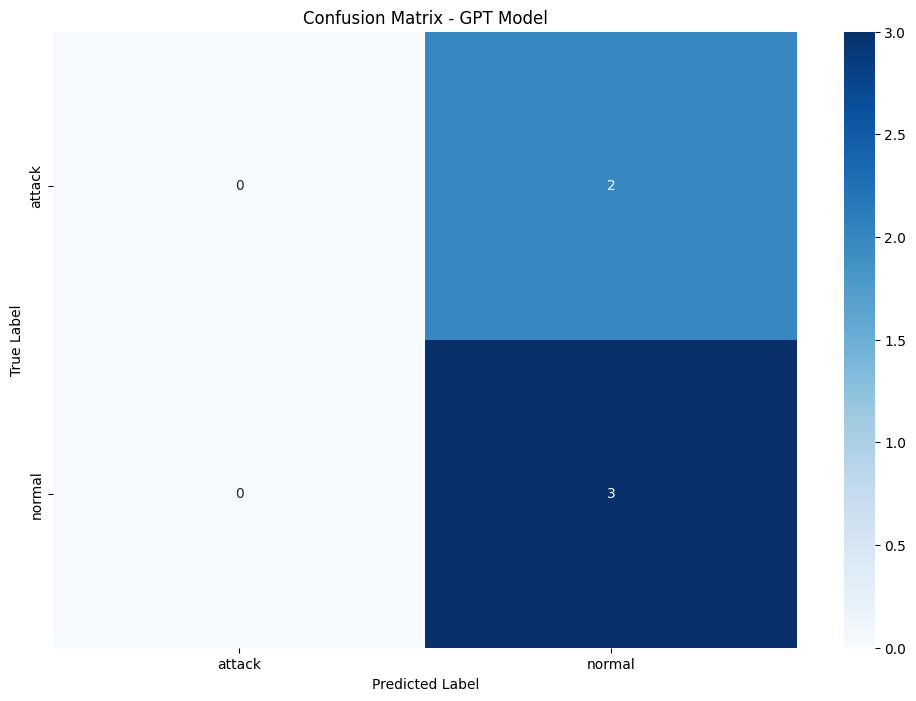

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df_test['Label'], df_test['prediction'])

labels = sorted(df_test['Label'].unique())

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - GPT Model")

plt.show()

In [77]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(df_test['Label'], df_test['prediction'], output_dict=True)

df_report = pd.DataFrame(report).transpose()

print(df_report)

              precision  recall  f1-score  support
attack             0.00     0.0     0.000      2.0
normal             0.60     1.0     0.750      3.0
accuracy           0.60     0.6     0.600      0.6
macro avg          0.30     0.5     0.375      5.0
weighted avg       0.36     0.6     0.450      5.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


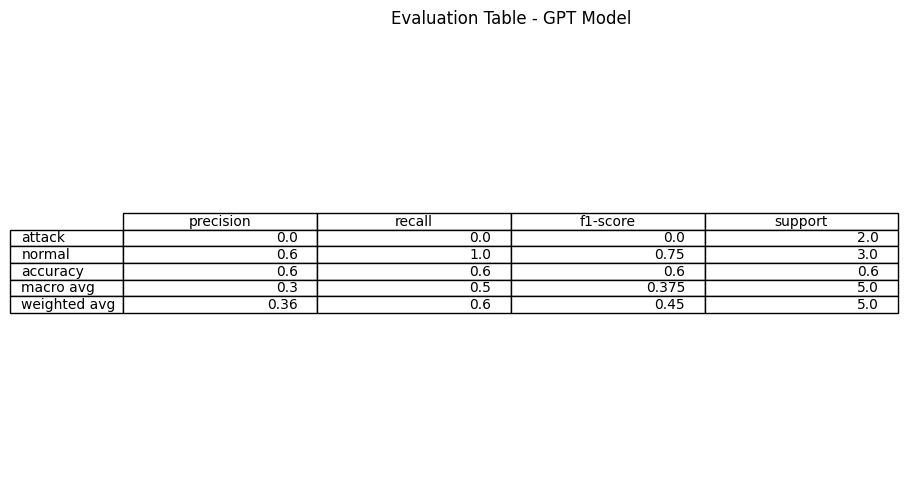

In [79]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=df_report.round(3).values,
    colLabels=df_report.columns,
    rowLabels=df_report.index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Evaluation Table - GPT Model")
plt.show()

In [81]:
print(df_test['Label'].unique())
print(df_test['prediction'].unique())

['normal' 'attack']
['normal']
